# Calibration

**This notebook assesses calibration performance of the gradient boosted survival model trained on chemo-only patients and recalibrates predictions using isotonic regression for patients with MSI-H metastatic colorectal cancer receiving first-line pembrolizumab or chemotherapy.**

In [1]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from scipy.stats import linregress
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed
from sklearn.isotonic import IsotonicRegression
from sksurv.metrics import brier_score

from utils.calibration import calculate_calibration_curve, calibrate_survival_predictions

## Import Data

In [2]:
survival_predictions_pembro_df = pd.read_csv('../outputs/gb_survival_predictions_pembro_chemo.csv')

In [3]:
survival_predictions_pembro_df.shape

(469, 212)

In [4]:
survival_predictions_chemo_df = pd.read_csv('../outputs/gb_survival_predictions_chemo_chemo.csv')

In [5]:
survival_predictions_chemo_df.shape

(25782, 202)

In [6]:
survival_predictions_df = pd.concat([survival_predictions_pembro_df, survival_predictions_chemo_df])

In [7]:
survival_predictions_df.shape

(26251, 213)

In [8]:
survival_predictions_df = survival_predictions_df[['PatientID', 'psurv_180']]

In [9]:
survival_predictions_df.shape

(26251, 2)

In [10]:
dtype_map = pd.read_csv('../outputs/pembro_chemo_features_dtypes.csv', index_col = 0).iloc[:, 0].to_dict()
pembro_pembrochemo_df = pd.read_csv('../outputs/pembro_chemo_features_df.csv', dtype = dtype_map)

In [11]:
pembro_pembrochemo_df.shape

(1208, 170)

In [12]:
df = pd.merge(pembro_pembrochemo_df, survival_predictions_df, on = 'PatientID', how = 'left')

In [13]:
df.shape

(1208, 171)

In [14]:
df = df.query('met_diagnosis_year <= 2023')

In [15]:
df.shape

(1074, 171)

## Raw Calibration Assessment

In [16]:
cal_df = calculate_calibration_curve(df, 'psurv_180', 180)

In [17]:
cal_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(0.016399999999999998, 0.681]",0.485909,0.412350,108,0.310168,0.495984
1,"(0.681, 0.818]",0.766617,0.722342,107,0.625677,0.798033
2,"(0.818, 0.865]",0.843733,0.742993,107,0.643684,0.812353
3,"(0.865, 0.898]",0.881851,0.865158,108,0.781766,0.917121
4,"(0.898, 0.917]",0.907194,0.789057,107,0.690987,0.850652
5,"(0.917, 0.931]",0.924640,0.881318,107,0.796484,0.928272
6,"(0.931, 0.942]",0.935943,0.894563,108,0.808546,0.934482
7,"(0.942, 0.954]",0.947223,0.961615,107,0.890210,0.980568
8,"(0.954, 0.966]",0.960030,0.971244,107,0.913496,0.990634
9,"(0.966, 0.993]",0.974668,0.981219,108,0.925162,0.994597


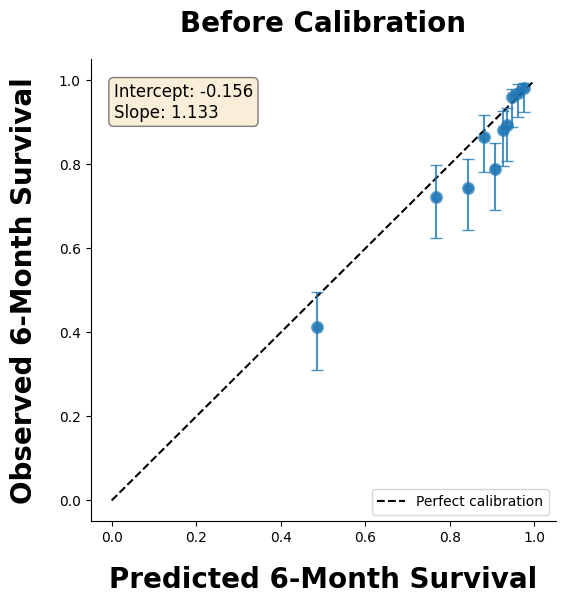

In [18]:
slope_orig, intercept_orig, _, _, _ = linregress(
    cal_df['predicted'], 
    cal_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_df['predicted'], cal_df['observed'], s = 70, alpha = 0.6)
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_df['observed'] - cal_df['obs_lo'],
    cal_df['obs_hi'] - cal_df['observed']
])

plt.errorbar(
    cal_df['predicted'],
    cal_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,    
    capsize = 4,         
    alpha = 0.8
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_orig:.3f}\nSlope: {slope_orig:.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 12, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'wheat', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.title('Before Calibration',  weight = 'bold', size = 20, pad = 20)
plt.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()

## Isotonic Calibration Using Cross Validation 

In [19]:
# Prepare structured array for survival outcomes
y_dtype = [('event', bool), ('duration', float)]

y = np.array([tuple(x) for x in df[['event', 'duration']].values],
             dtype = y_dtype)

In [20]:
df, brier_scores = calibrate_survival_predictions(df, y, 'psurv_180', 180)


=== Fold 1/5 ===
Brier score at 180 days (calibrated): 0.1330

=== Fold 2/5 ===
Brier score at 180 days (calibrated): 0.1140

=== Fold 3/5 ===
Brier score at 180 days (calibrated): 0.1129

=== Fold 4/5 ===
Brier score at 180 days (calibrated): 0.1258

=== Fold 5/5 ===
Brier score at 180 days (calibrated): 0.1214

=== Summary ===
psurv_180_calibrated computed: 1074

=== Brier Scores at 180 days (calibrated) ===
Mean: 0.1214 ± 0.0075


In [21]:
df_final_calibrated = df[['PatientID', 'psurv_180_calibrated']]

In [22]:
df_final_calibrated.to_csv('../outputs/gb_6m_survival_predictions_calibrated_chemo.csv', index = False)

In [23]:
cal_iso_df = calculate_calibration_curve(df, 'psurv_180_calibrated', 180)

In [24]:
cal_iso_df

,bin,predicted,observed,n,obs_lo,obs_hi
0,"(-0.001, 0.556]",0.409047,0.445980,118,0.346685,0.526443
1,"(0.556, 0.755]",0.692477,0.702958,106,0.605198,0.780855
2,"(0.755, 0.813]",0.794456,0.808427,135,0.724690,0.862325
3,"(0.813, 0.832]",0.821601,0.846734,100,0.754067,0.901421
4,"(0.832, 0.838]",0.837983,0.785824,82,0.675250,0.858795
5,"(0.838, 0.902]",0.883563,0.870469,113,0.791041,0.921182
6,"(0.902, 0.925]",0.906947,0.896626,102,0.804435,0.935752
7,"(0.925, 0.969]",0.960489,0.957250,121,0.898213,0.980956
8,"(0.969, 0.98]",0.973131,0.977778,92,0.903447,0.990356
9,"(0.98, 1.0]",0.997320,0.970965,105,0.912685,0.990543


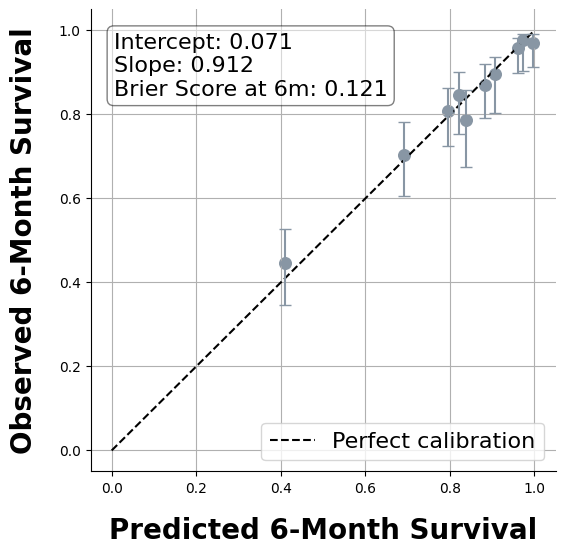

In [25]:
slope_iso, intercept_iso, _, _, _ = linregress(
    cal_iso_df['predicted'], 
    cal_iso_df['observed']
)

# Plot
plt.figure(figsize = (6, 6))
plt.scatter(cal_iso_df['predicted'], cal_iso_df['observed'], s = 70, color='#8896A4')
plt.plot([0, 1], [0, 1], 'k--', label = 'Perfect calibration')

# Error bar 
yerr = np.vstack([
    cal_iso_df['observed'] - cal_iso_df['obs_lo'],
    cal_iso_df['obs_hi'] - cal_iso_df['observed']
])

plt.errorbar(
    cal_iso_df['predicted'],
    cal_iso_df['observed'],
    yerr = yerr,
    fmt = 'o',           
    elinewidth = 1.5,
    color = '#8896A4',
    capsize = 4
)

# Add text box with calibration metrics
textstr = f'Intercept: {intercept_iso:.3f}\nSlope: {slope_iso:.3f}\nBrier Score at 6m: {np.mean(brier_scores):.3f}'
plt.text(0.05, 0.95, textstr, transform = plt.gca().transAxes, 
         fontsize = 16, verticalalignment = 'top',
         bbox = dict(boxstyle = 'round', facecolor = 'white', alpha = 0.5))

plt.xlabel('Predicted 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
plt.ylabel('Observed 6-Month Survival', weight = 'bold', labelpad = 15, size = 20)
#plt.title('After Isotonic Regression',  weight = 'bold', size = 20, pad = 20)
plt.legend(fontsize=16)
plt.grid(True)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()